# Step 1 :  Problem Framing & Theory Notes

## Q1. What is Regression? How is it different from Classification? Give 2 real-world Indian examples 

* Regression is a supervised machine learning technique used to predict a continuous numerical value based on one or more input features. It learns the relationship between independent variables (features) and a dependent variable (target). Regression is commonly used for forecasting prices, sales, temperatures, or demand.

* Regression predicts continuous numerical values, such as house prices or monthly income. Classification predicts categorical labels or classes, such as spam/not spam or fraud/not fraud. In simple terms, regression answers "How much?", while classification answers "Which category?".

* Predicting EMI at HDFC Bank: Regression can estimate the monthly EMI amount based on loan amount, interest rate, and loan tenure, helping customers plan their finances.

* Predicting Crop Yield in Maharashtra: Regression can predict crop production (in tonnes per hectare) using factors like rainfall, temperature, soil quality, and fertilizer usage, helping farmers make better decisions.

## Q2. What is the difference between Simple Linear Regression, Multiple Linear Regression, and Regularised Regression (Ridge / Lasso)?

* Simple Linear Regression (SLR) is used to predict a continuous target variable using only one independent variable while, Multiple Linear Regression (MLR) is used to predict a continuous target variable using two or more independent variables and finally Regularized Regression is an extension of MLR that adds a penalty term to reduce overfitting and improve model generalization. 

## Q3. Explain Overfitting and Underfitting. How does regularisation (L1/L2) help prevent them?

* Overfitting refers to when a Model performs well / better on training Data but unfortunately performs poor on testing Data. 

* Underfitting refers to when a Model poorly performs on Both training & testing Data. 

* Regularisation reduces overfitting by adding a penalty term to the loss function, preventing the model from learning overly complex patterns. L2 (Ridge) shrinks the coefficients toward zero but keeps all features, while L1 (Lasso) can shrink some coefficients exactly to zero, effectively removing less important features. This makes the model simpler and improves its ability to generalize to unseen data.

## Q4. Define RMSE, MAE, and R². When would you prefer RMSE over MAE?

* RMSE measures the average prediction errors by taking the square root of the average squared differences between actual and predicted values. It gives more weight to larger errors, making it sensitive to outliers. A lower RMSE indicates better model performance.

* MAE measures the average absolute difference between actual and predicted values. It treats all errors equally, regardless of their size, making it less sensitive to outliers than RMSE. A lower MAE indicates more accurate predictions.

* R² measures how well a regression model explains the variation in the target variable. Its value ranges from 0 to 1, where a value closer to 1 indicates a better fit. For example, an R² of 0.90 means the model explains 90% of the variance in the target variable.

* RMSE is preferred when large prediction errors are more costly and should be penalized heavily. Since RMSE squares the errors, it gives greater importance to large mistakes than MAE. For example, in house price prediction or loan amount estimation, a large error is much more serious than several small errors, making RMSE a better evaluation metric.

## Q5. What is Cross-Validation (k-Fold)? Why is it preferred over a single train-test split for model evaluation?

* Cross-Validation (k-Fold) is a model evaluation technique in which the dataset is divided into k equal folds. The model is trained on k−1 folds and tested on the remaining fold. This process is repeated k times, with each fold used once as the test set. The final performance is the average of all k evaluation scores.

* A single train-test split evaluates the model using only one partition of the data, so the result may depend on that particular split. In opposite, k-Fold Cross-Validation uses every data point for both training and testing, providing a more reliable and stable estimate of model performance. It also reduces the risk of biased evaluation and makes better use of limited data.



## Step 2 :  Dataset Loading & Exploratory Data Analysis

### Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib
from scipy.stats import probplot , f_oneway

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder , StandardScaler , FunctionTransformer , OrdinalEncoder

from sklearn.model_selection import train_test_split , KFold , RandomizedSearchCV 

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression , RidgeCV , LassoCV

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

### 2.1 -->  Load & Understand the Dataset

In [2]:
original_data = pd.read_csv('../Dataset/Ames Housing Dataset.csv')

df = original_data.copy()

df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


### Basic Info.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns

print("Number of Numerical Columns : ", len(num_cols))

cat_cols = df.select_dtypes(include = ['object']).columns

print("Number of Categorical Columns : ", len(cat_cols))

Number of Numerical Columns :  38
Number of Categorical Columns :  43


In [5]:
missing_cols = df.columns[df.isnull().sum() > 0]

print("Number of Columns with Missing Values :", len(missing_cols))

print("\nColumns having missing values:")
print(missing_cols.tolist())

Number of Columns with Missing Values : 19

Columns having missing values:
['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


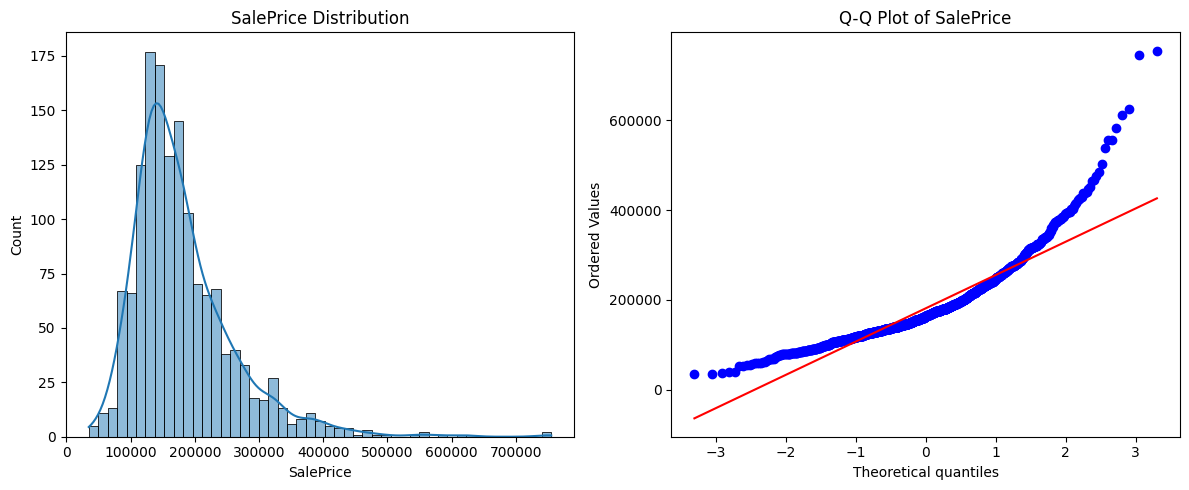

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")

plt.subplot(1,2,2)
probplot(df['SalePrice'], dist='norm', plot=plt)
plt.title("Q-Q Plot of SalePrice")

plt.tight_layout()
plt.show()

* The original SalePrice variable is right-skewed and not normally distributed. In the Q-Q plot, many points deviate from the straight line, indicating non-normality.

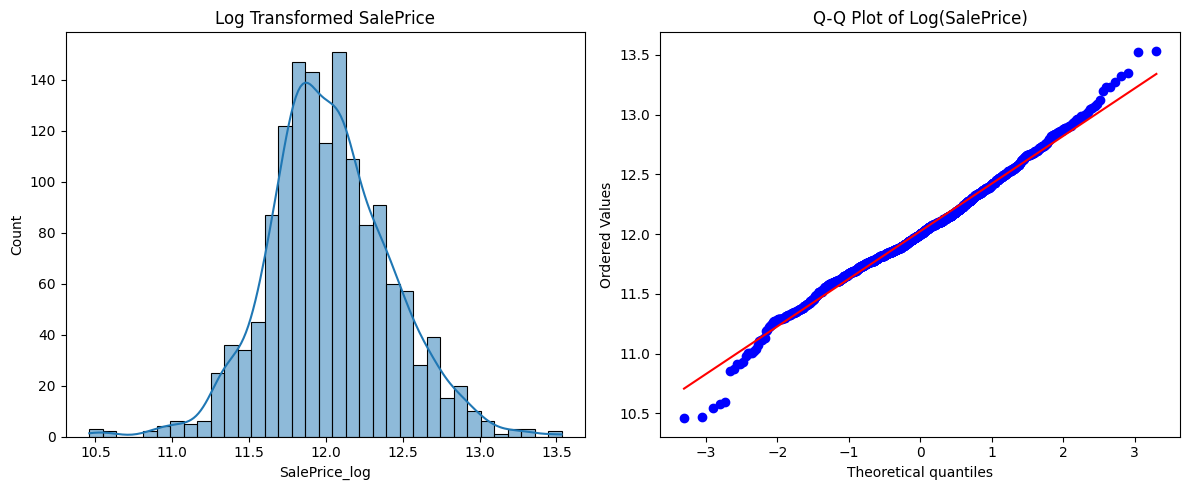

In [7]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice_log'], kde=True)
plt.title("Log Transformed SalePrice")

plt.subplot(1,2,2)
probplot(df['SalePrice_log'], dist='norm', plot=plt)
plt.title("Q-Q Plot of Log(SalePrice)")

plt.tight_layout()
plt.show()

* After applying log1p transformation, the distribution becomes more symmetric. The Q-Q plot points align more closely with the diagonal line, indicating an approximately normal distribution. Therefore, log1p(SalePrice) is preferred for regression modeling.

## 2.2 --> Univariate Analysis

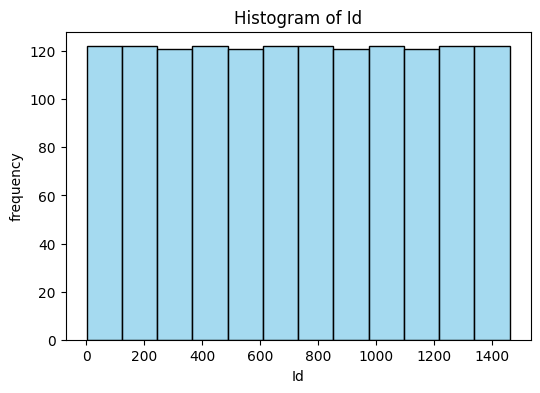

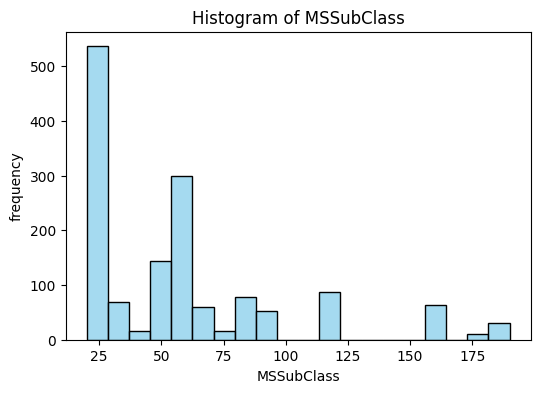

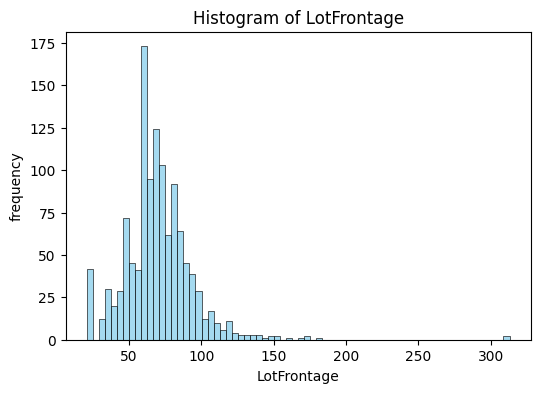

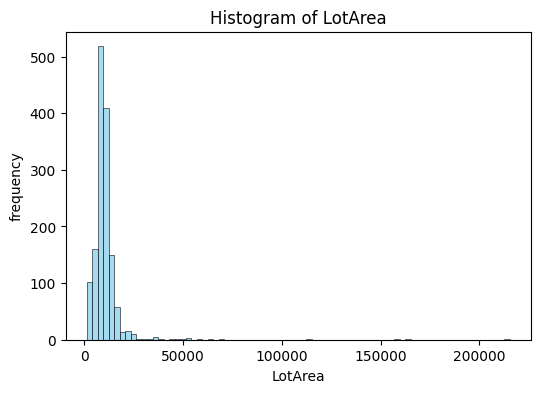

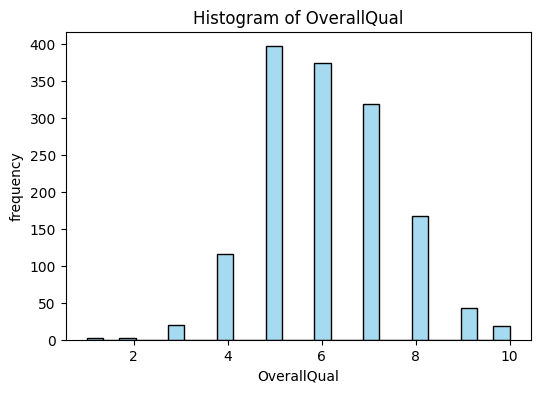

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], edgecolor = 'black' , color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

skewness = df[num_cols].skew()

top_5_skewed = skewness.abs().sort_values(ascending = False).head(5)

print("Top 5 Most Skewed Columns:")
print(top_5_skewed)

In [ ]:
anova_results = []

for col in cat_cols:

    groups = [
        group['SalePrice'].dropna().values
        for _, group in df.groupby(col)
    ]

    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        'Feature': col,
        'F-Statistic': f_stat,
        'P-Value': p_value
    })

anova_df = pd.DataFrame(anova_results).sort_values(by='F-Statistic' , ascending = False)

print(anova_df)


          Feature  F-Statistic        P-Value
18      ExterQual   443.334831  1.439551e-204
30    KitchenQual   407.806352  3.032213e-192
21       BsmtQual   392.913506  9.610615e-186
34   GarageFinish   250.962467   1.199117e-93
20     Foundation   100.253851   5.791895e-91
28     CentralAir    98.305344   1.809506e-22
27      HeatingQC    88.394462   2.667062e-67
8    Neighborhood    71.784865  1.558600e-225
33     GarageType    71.522123   1.247154e-66
23   BsmtExposure    70.887984   1.022671e-42
24   BsmtFinType1    67.602175   1.807731e-63
42  SaleCondition    45.578428   7.988268e-44
0        MSZoning    43.840282   8.817634e-35
37     PavedDrive    42.024179   1.803569e-18
3        LotShape    40.132852   6.447524e-25
2           Alley    35.562060   4.899826e-08
17     MasVnrType    30.746119   2.010580e-13
41       SaleType    28.863054   5.039767e-42
32    FireplaceQu    24.398929   5.016300e-19
29     Electrical    23.067673   1.663249e-18
12     HouseStyle    19.595001   3

* ANOVA was performed on all categorical features to identify their relationship with the target variable (SalePrice). Features with higher F-statistics and p-values less than 0.05 were considered more influential. Based on the results, ExterQual, KitchenQual, BsmtQual & GarageFinish were identified as the most impactful categorical features and selected for further visualization and analysis.

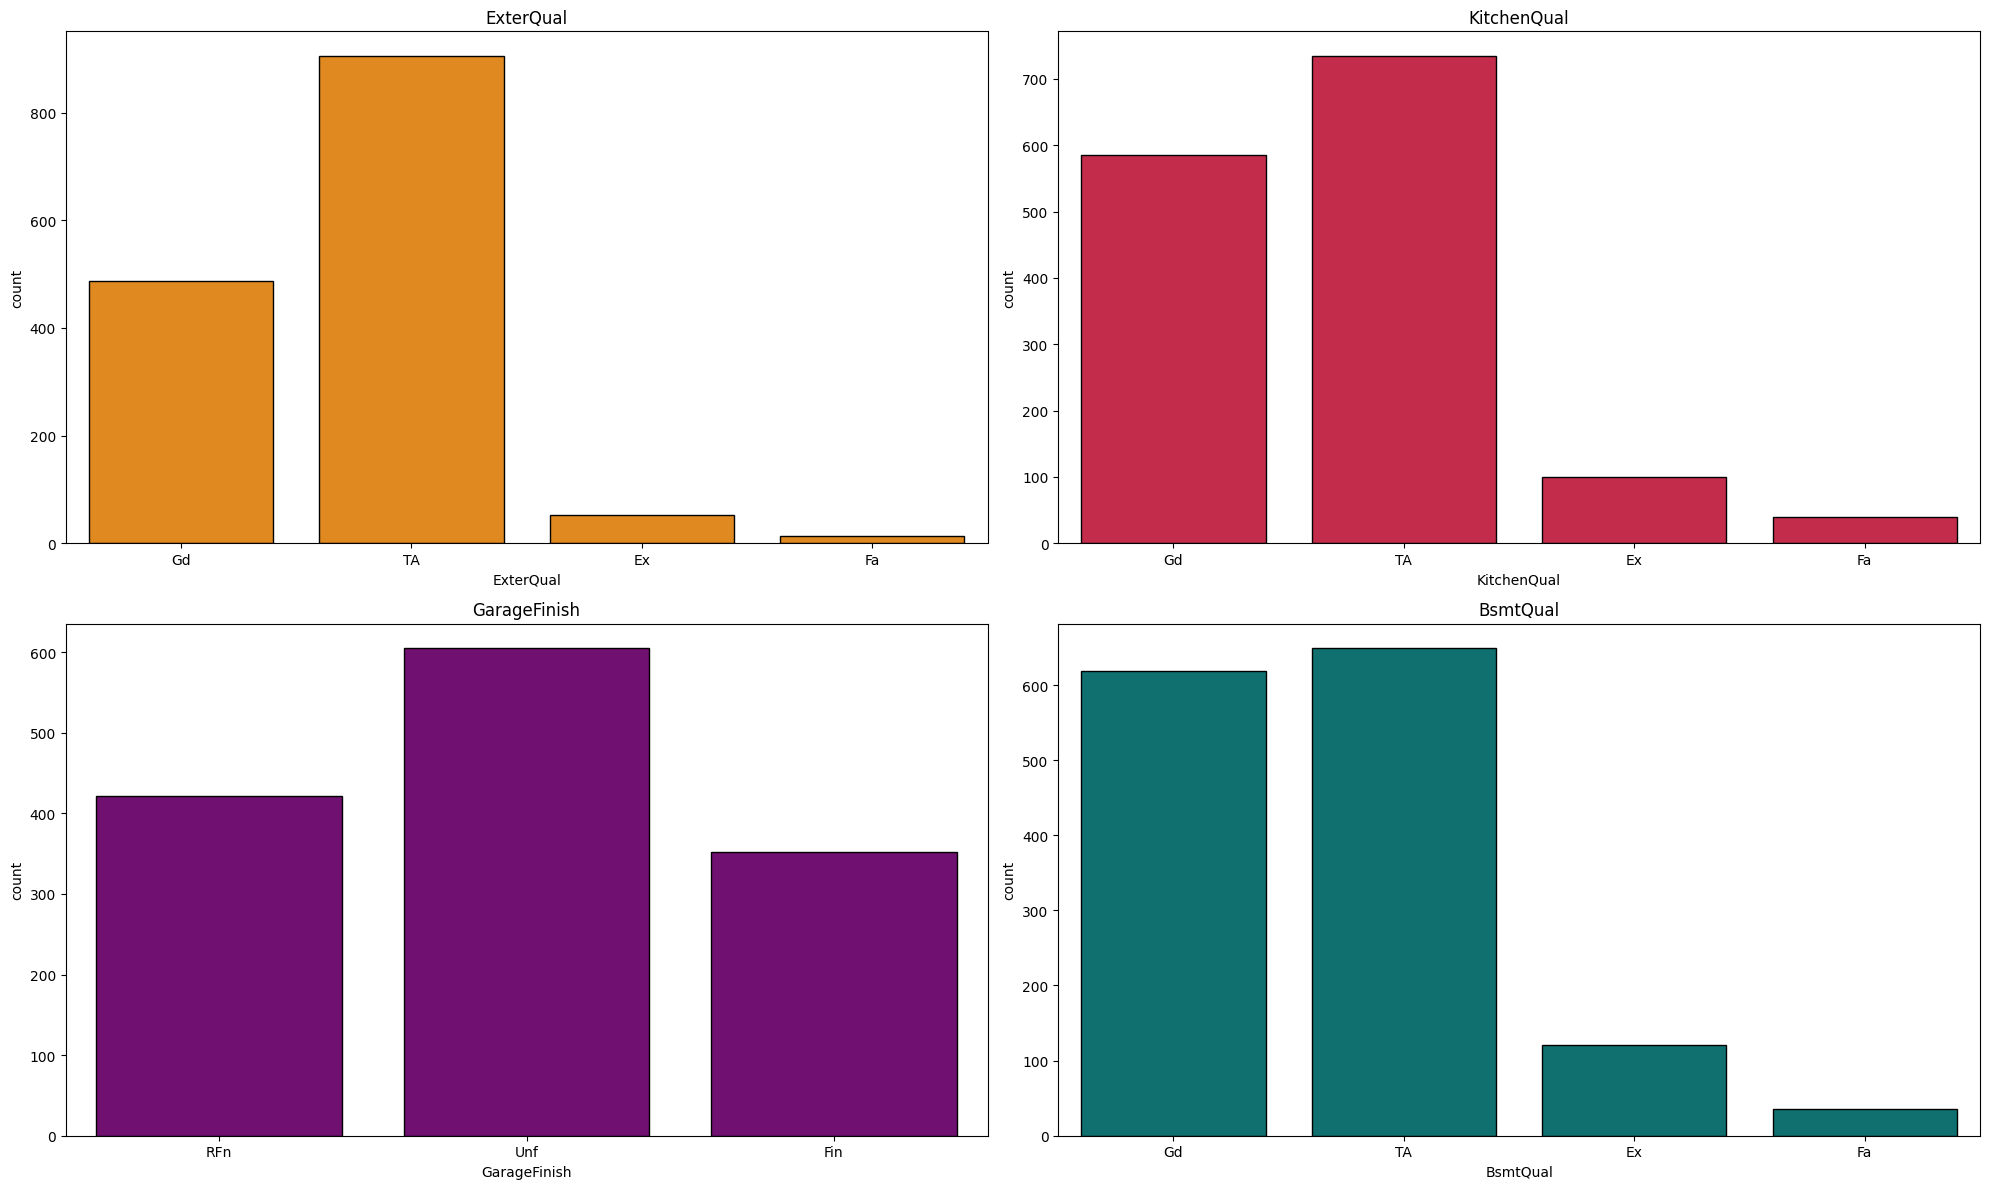

In [ ]:
fig , ax = plt.subplots( 2 , 2 , figsize = (20 , 12))

sns.countplot(x = 'ExterQual' , data = df , color = 'darkorange' , edgecolor = 'black' , ax = ax[0,0])
ax[0,0].set_title('ExterQual')

sns.countplot(x = 'KitchenQual' , data = df , color = 'crimson' , edgecolor = 'black' , ax = ax[0,1])
ax[0,1].set_title('KitchenQual')

sns.countplot(x = 'GarageFinish' , data = df , color = 'purple' , edgecolor = 'black' , ax = ax[1,0])
ax[1,0].set_title('GarageFinish')

sns.countplot(x = 'BsmtQual' , data = df , color = 'teal' , edgecolor = 'black' , ax = ax[1,1])
ax[1,1].set_title('BsmtQual')

plt.tight_layout()
plt.show()

## 2.3 --> Bivariate & Multivariate Analysis

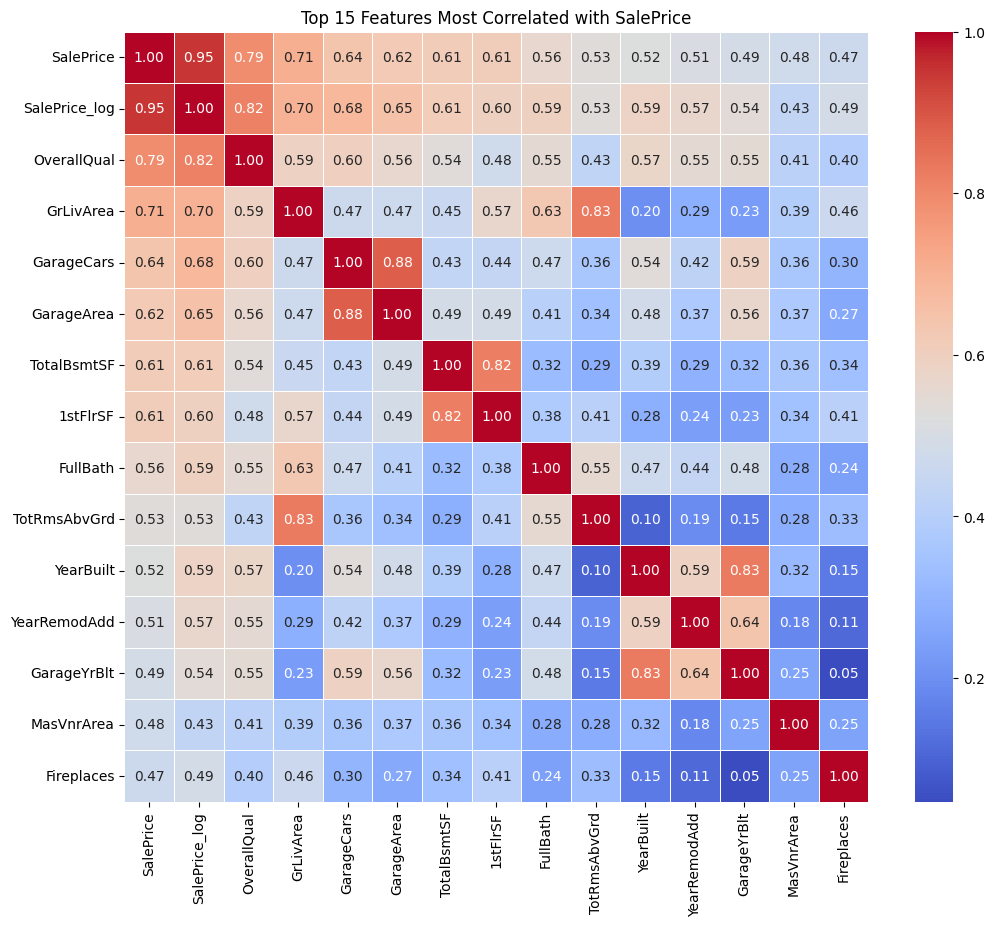

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])

top_15_features = (num_df.corr()['SalePrice'].abs().sort_values(ascending=False).head(15).index)

corr_matrix = num_df[top_15_features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix , annot = True , cmap  = 'coolwarm' , fmt = '.2f' , linewidths=0.5)

plt.title('Top 15 Features Most Correlated with SalePrice')
plt.show()

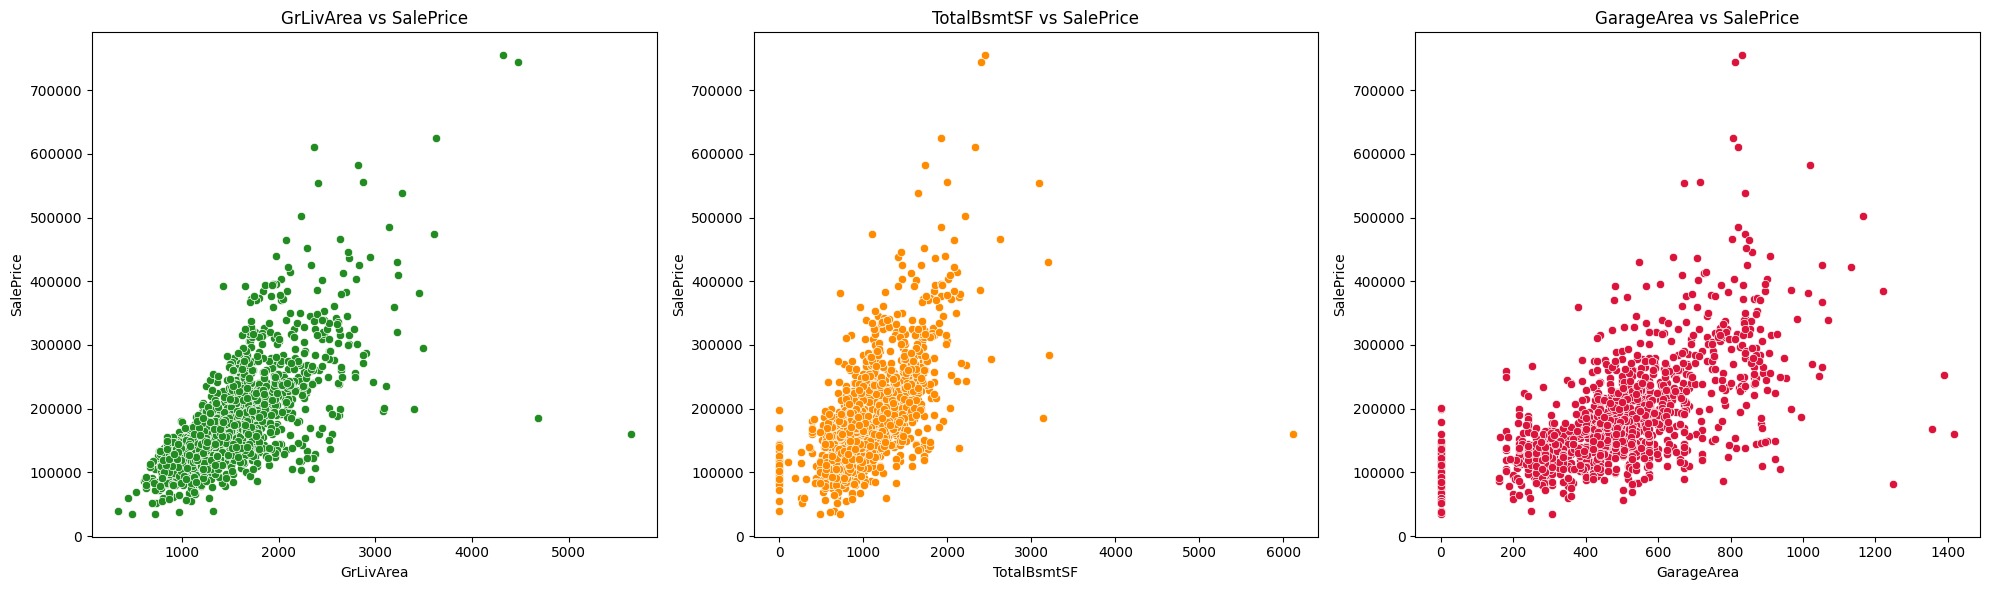

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x = 'GrLivArea' , y = 'SalePrice' , data = df , color = 'forestgreen' , ax = ax[0])
ax[0].set_title('GrLivArea vs SalePrice')

sns.scatterplot(x = 'TotalBsmtSF', y = 'SalePrice' , data = df , color='darkorange' , ax = ax[1])
ax[1].set_title('TotalBsmtSF vs SalePrice')

sns.scatterplot(x = 'GarageArea' ,  y = 'SalePrice' , data = df , color = 'crimson' ,  ax = ax[2])
ax[2].set_title('GarageArea vs SalePrice')

plt.tight_layout()
plt.show()

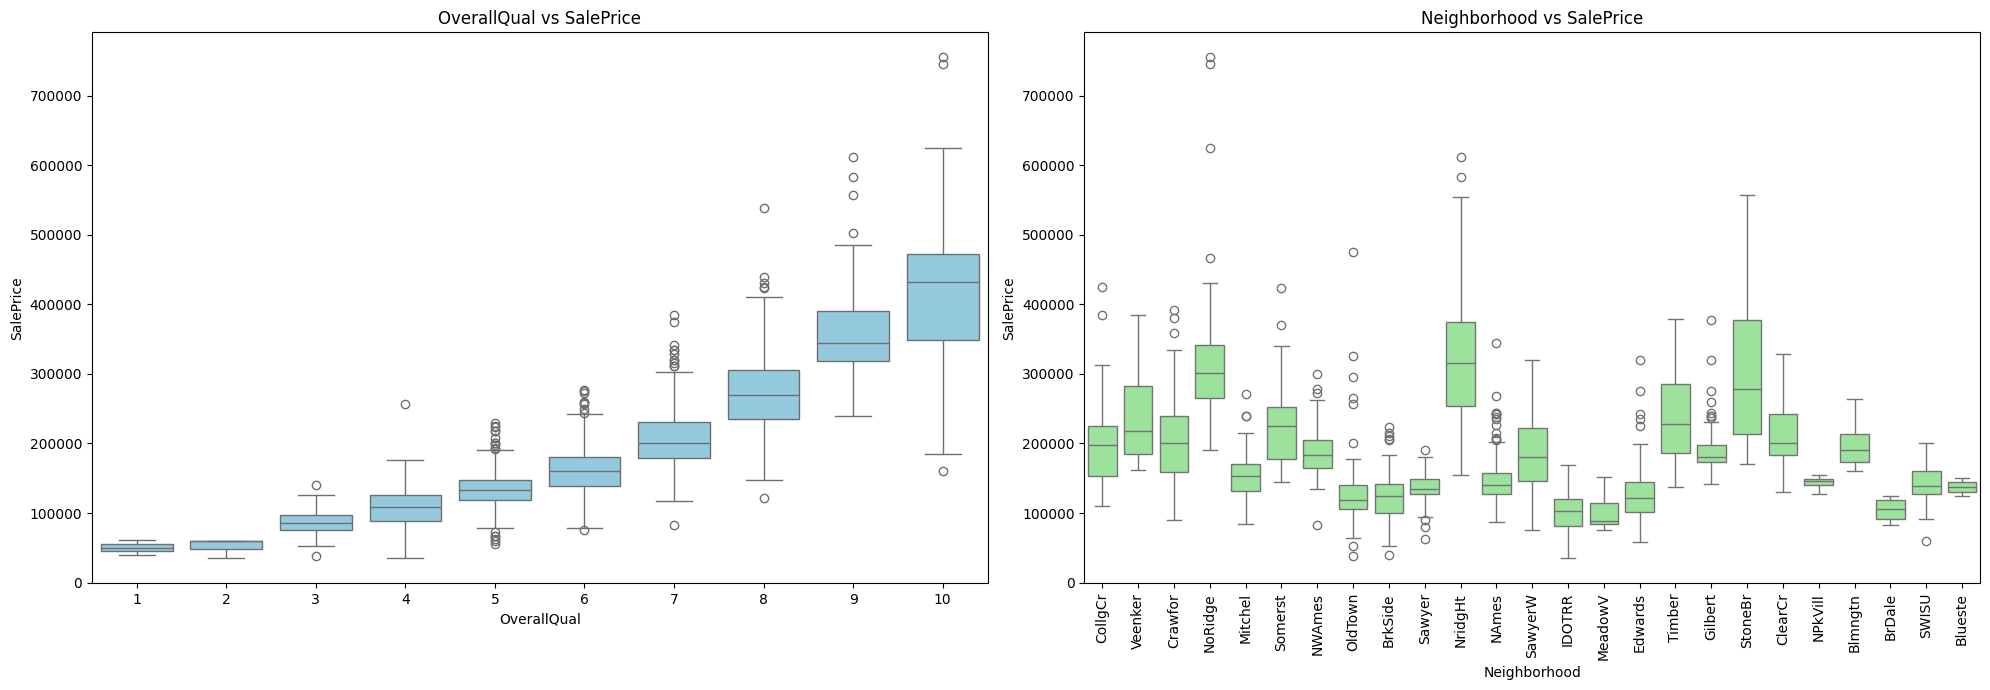

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

sns.boxplot(x = 'OverallQual' , y = 'SalePrice' , data = df , color = 'skyblue' , ax = ax[0])
ax[0].set_title('OverallQual vs SalePrice')

sns.boxplot(x = 'Neighborhood' , y = 'SalePrice' , data = df , color = 'lightgreen' , ax = ax[1])
ax[1].set_title('Neighborhood vs SalePrice')
ax[1].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(10)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Name: SalePrice, dtype: float64

* According to above results it is clear that NoRidge Neighborhood is the priciest.

In [ ]:
df.sort_values(by='GrLivArea', ascending=False)[['GrLivArea', 'SalePrice']].head(10)

,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000
1169,3627,625000
185,3608,475000
304,3493,295000
1268,3447,381000
635,3395,200000
769,3279,538000


* From the above results, the First Two houses have extremely large GrLivArea but relatively low SalePrice, making them clear outliers. They do not follow the general positive relationship between living area and sale price.

### Outlier Removal Before Train Test Split

In [ ]:
outliers = df[
    ((df['GrLivArea'] == 5642) & (df['SalePrice'] == 160000)) |
    ((df['GrLivArea'] == 4676) & (df['SalePrice'] == 184750))
].index

df = df.drop(outliers)

* These two houses have an unusually large living area but were sold at very low prices, making them outliers. Keeping them can distort the fitted regression line, increase prediction error, and reduce the overall accuracy of a linear regression model.

## Step 3: Data Preprocessing & Feature Engineering

### 3.1 --> Train Test Split

In [ ]:
X = df.drop(['SalePrice' , 'SalePrice_log'] ,  axis = 1)
y = df['SalePrice']

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 10)

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

### 3.2 -->  Handle Missing Values

In [ ]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing['Missing Values'] > 0]

missing.sort_values(by = 'Missing %' ,  ascending = False)

,Missing Values,Missing %
PoolQC,1452,99.588477
MiscFeature,1404,96.296296
Alley,1367,93.758573
Fence,1177,80.727023
MasVnrType,872,59.807956
FireplaceQu,690,47.325103
LotFrontage,259,17.764060
GarageType,81,5.555556
GarageYrBlt,81,5.555556
GarageFinish,81,5.555556


In [ ]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

X_train.drop(columns = cols_to_drop , inplace = True)
X_test.drop(columns = cols_to_drop , inplace = True)

In [ ]:
none_cols = ['GarageType','GarageFinish','GarageQual','GarageCond','BsmtFinType2','BsmtExposure','BsmtFinType1',
                'BsmtCond','BsmtQual','FireplaceQu','MasVnrType']

cat_imputer = SimpleImputer(strategy = 'constant' , fill_value = 'None')

X_train[none_cols] = cat_imputer.fit_transform(X_train[none_cols])
X_test[none_cols] = cat_imputer.transform(X_test[none_cols])

In [ ]:
num_zero_cols = ['GarageYrBlt','MasVnrArea']

zero_imputer = SimpleImputer(strategy = 'constant' , fill_value = 0)

X_train[num_zero_cols] = zero_imputer.fit_transform(X_train[num_zero_cols])
X_test[num_zero_cols] = zero_imputer.transform(X_test[num_zero_cols])

In [ ]:
median_imputer = SimpleImputer(strategy='median')

X_train[['LotFrontage']] = median_imputer.fit_transform(X_train[['LotFrontage']])
X_test[['LotFrontage']] = median_imputer.transform(X_test[['LotFrontage']])

In [ ]:
mode_imputer = SimpleImputer(strategy='most_frequent')

X_train[['Electrical']] = mode_imputer.fit_transform(X_train[['Electrical']])
X_test[['Electrical']] = mode_imputer.transform(X_test[['Electrical']])

### 3.3 --> Feature Engineering

In [ ]:
X_train['TotalSF'] = X_train['TotalBsmtSF'] + X_train['1stFlrSF'] + X_train['2ndFlrSF']
X_test['TotalSF'] = X_test['TotalBsmtSF'] + X_test['1stFlrSF'] + X_test['2ndFlrSF']

X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']
X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']

X_train['RemodAge'] = X_train['YrSold'] - X_train['YearRemodAdd']
X_test['RemodAge'] = X_test['YrSold'] - X_test['YearRemodAdd']

X_train['HasGarage'] = (X_train['GarageArea'] > 0).astype(int)
X_test['HasGarage'] = (X_test['GarageArea'] > 0).astype(int)

X_train['HasPool'] = (X_train['PoolArea'] > 0).astype(int)
X_test['HasPool'] = (X_test['PoolArea'] > 0).astype(int)

### 3.4 --> Encoding & Scaling

In [ ]:
maping = {
    'None' : 0,
    'Po' : 1 ,
    'Fa' : 2 ,
    'TA' : 3 ,
    'Gd' : 4 ,
    'Ex' : 5 
}

ordinal_cols = ['ExterQual' , 'KitchenQual' , 'BsmtQual' , 'FireplaceQu']

for col in ordinal_cols:
    X_train[col] = X_train[col].map(maping)
    X_test[col] = X_test[col].map(maping)


In [ ]:
num_col = X_train.select_dtypes(include=['int64', 'float64']).columns

skewness = X_train[num_col].skew()

skewed_col = skewness[skewness > 0.75].index

print(skewed_col)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'ExterQual',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF', 'HasPool'],
      dtype='object')


In [ ]:
X_train[skewed_col] = np.log1p(X_train[skewed_col])

X_test[skewed_col] = np.log1p(X_test[skewed_col])

In [ ]:
continuous_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.drop(ordinal_cols)

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [ ]:
cat_col = X_train.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_col)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
cardinality = X_train[cat_col].nunique().sort_values(ascending=False)

print(cardinality)

Neighborhood     24
Exterior2nd      16
Exterior1st      15
SaleType          9
Condition1        9
HouseStyle        8
BsmtFinType1      7
BsmtFinType2      7
GarageType        7
Functional        7
Condition2        7
RoofMatl          6
Foundation        6
SaleCondition     6
RoofStyle         6
GarageQual        6
GarageCond        6
BsmtExposure      5
Heating           5
Electrical        5
MSZoning          5
BsmtCond          5
BldgType          5
LotConfig         5
ExterCond         5
MasVnrType        4
HeatingQC         4
GarageFinish      4
LandContour       4
LotShape          4
LandSlope         3
PavedDrive        3
Street            2
CentralAir        2
Utilities         2
dtype: int64


* Neighborhood was retained because it has high predictive power for SalePrice. Although it has 25 categories, its cardinality is not high enough to justify dropping the feature, and One-Hot Encoding can handle it effectively.

## Step 4 : Regression Models ----> Linear , Ridge & Lasso

### 4.1 --> Linear Regression (Baseline)

In [ ]:
Linear_Regression = LinearRegression()

Linear_Regression.fit(X_train_processed , y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred_log = Linear_Regression.predict(X_test_processed)

In [ ]:
y_pred_lr = np.expm1(y_pred_log)
y_actual = np.expm1(y_test_log)

In [ ]:
print("RMSE :", np.sqrt(mean_squared_error(y_actual, y_pred_lr)))
print("MAE :", mean_absolute_error(y_actual, y_pred_lr))
print("R2 Score :", r2_score(y_actual, y_pred_lr))

RMSE : 20767.515876711397
MAE : 14587.421726242792
R2 Score : 0.9157153149057364


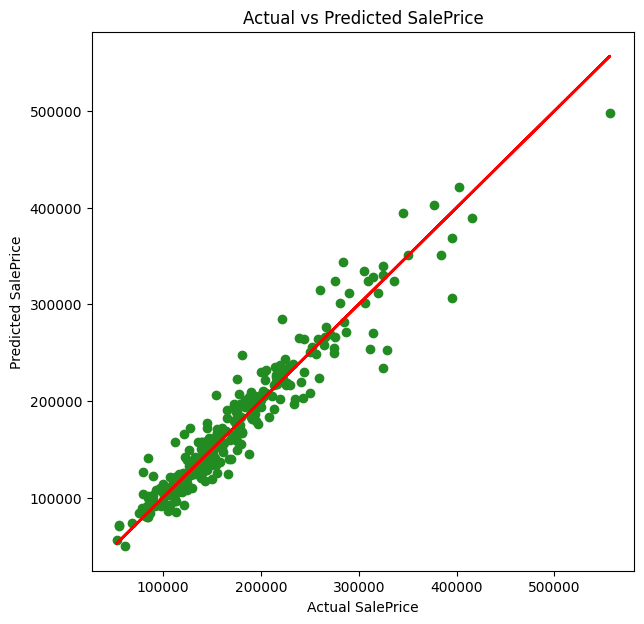

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_lr, color='forestgreen')

plt.plot(y_actual,y_actual,color='red',linewidth=2)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")

plt.show()

* The points are mostly close to the red diagonal line, showing that the Linear Regression model's predictions are reasonably close to the actual SalePrice. However, some points are farther from the line, especially for higher-priced houses, indicating larger prediction errors.

### 4.2 --> Ridge Regression (L2)

In [ ]:
Ridge_Regression = RidgeCV(alphas = [0.01, 0.1, 1, 10, 100] , cv = 5)

Ridge_Regression.fit(X_train_processed, y_train_log)

print("Best Alpha:", Ridge_Regression.alpha_)

Best Alpha: 10.0


In [ ]:
y_pred_log_ridge = Ridge_Regression.predict(X_test_processed)
y_pred_ridge = np.expm1(y_pred_log_ridge)

In [ ]:
print("RMSE :", np.sqrt(mean_squared_error(y_actual, y_pred_ridge)))
print("MAE :", mean_absolute_error(y_actual, y_pred_ridge))
print("R2 Score :", r2_score(y_actual, y_pred_ridge))

RMSE : 19269.883602212554
MAE : 13768.058555787584
R2 Score : 0.927433237321415


In [ ]:
feature_names = preprocessor.get_feature_names_out()

Ridge_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficients': Ridge_Regression.coef_
})

Ridge_coef_df['Absolute_Coefficients'] = Ridge_coef_df['Coefficients'].abs()


Ridge_top20 = Ridge_coef_df.sort_values(by = 'Absolute_Coefficients' , ascending = False).head(20)

print(Ridge_top20)

                          Feature  Coefficients  Absolute_Coefficients
0        onehot__MSZoning_C (all)     -0.137153               0.137153
30   onehot__Neighborhood_Crawfor      0.070394               0.070394
228        remainder__OverallQual      0.069333               0.069333
242          remainder__GrLivArea      0.068437               0.068437
182        onehot__Functional_Typ      0.066180               0.066180
46   onehot__Neighborhood_StoneBr      0.065523               0.065523
31   onehot__Neighborhood_Edwards     -0.059952               0.059952
265            remainder__TotalSF      0.051428               0.051428
229        remainder__OverallCond      0.048174               0.048174
93    onehot__Exterior1st_BrkFace      0.046708               0.046708
163          onehot__Heating_Grav     -0.045718               0.045718
227            remainder__LotArea      0.045196               0.045196
1             onehot__MSZoning_FV      0.044289               0.044289
2     

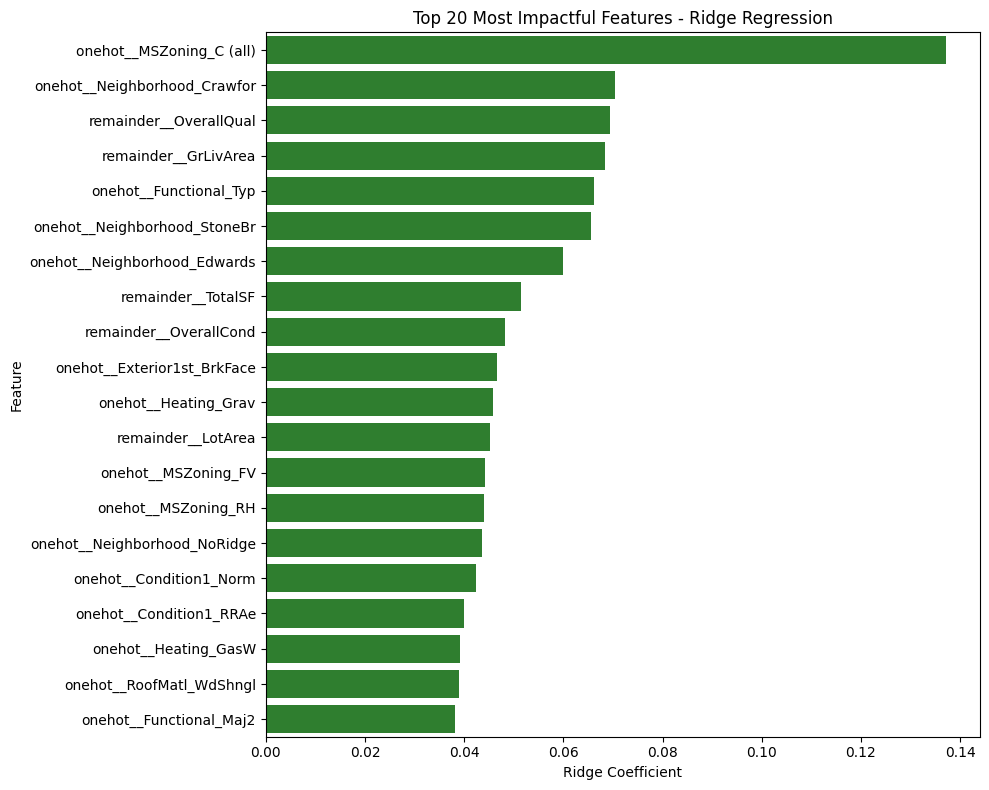

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(data = Ridge_top20 , x = 'Absolute_Coefficients' , y = 'Feature' , color = 'forestgreen')

plt.title('Top 20 Most Impactful Features - Ridge Regression')
plt.xlabel('Ridge Coefficient')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### 4.3 -->  Lasso Regression (L1)

In [ ]:
Lasso_Regression = LassoCV(alphas = [0.0001, 0.001, 0.01, 0.1, 1] ,  max_iter = 10000 , cv = 5)

Lasso_Regression.fit(X_train_processed, y_train_log)

print("Best Alpha:", Lasso_Regression.alpha_)

Best Alpha: 0.001


In [ ]:
y_pred_log_lasso = Lasso_Regression.predict(X_test_processed)

y_pred_lasso = np.expm1(y_pred_log_lasso)

In [ ]:
print("RMSE :", np.sqrt(mean_squared_error(y_actual, y_pred_lasso)))
print("MAE :", mean_absolute_error(y_actual, y_pred_lasso))
print("R2 Score :", r2_score(y_actual, y_pred_lasso))

RMSE : 19799.01758626021
MAE : 14423.625530174812
R2 Score : 0.9233932833372818


In [ ]:
zero_coefficients = np.sum(Lasso_Regression.coef_ == 0)

print("Number of features zeroed out:", zero_coefficients)

non_zero_coefficients = np.sum(Lasso_Regression.coef_ != 0)

print("Number of features retained:", non_zero_coefficients)

Number of features zeroed out: 190
Number of features retained: 80


In [ ]:
Comparison = pd.DataFrame({
    'Model' : ['Ridge Regression' , 'Lasso Regression'] ,
    'RMSE' : [root_mean_squared_error(y_actual, y_pred_ridge) , root_mean_squared_error(y_actual, y_pred_lasso)] ,
    'MAE' : [mean_absolute_error(y_actual, y_pred_ridge) , mean_absolute_error(y_actual, y_pred_lasso)] , 
    'R2 Score' : [r2_score(y_actual, y_pred_ridge) , r2_score(y_actual, y_pred_lasso)]
})

Comparison

,Model,RMSE,MAE,R2 Score
0,Ridge Regression,19269.883602,13768.058556,0.927433
1,Lasso Regression,19799.017586,14423.625530,0.923393


* Ridge Regression performed better than Lasso Regression. Ridge achieved a lower RMSE (19,269.88) and MAE (13,768.06), while also having a higher R² (0.9274) than Lasso. This suggests Ridge handled the correlated features better, while Lasso removed some features through L1 regularisation, which slightly reduced its predictive performance.

## Step 5: Advanced Models — Random Forest & XGBoost Regressor

### 5.1 --> Ranom Forest Regressor

In [ ]:
Random_Forest = RandomForestRegressor(n_estimators = 200 , max_depth = 10 , random_state = 42 , n_jobs = -1)

Random_Forest.fit(X_train_processed , y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
y_pred_log_rf = Random_Forest.predict(X_test_processed)

y_pred_rf = np.expm1(y_pred_log_rf)

In [ ]:
print("RMSE :", np.sqrt(mean_squared_error(y_actual, y_pred_rf)))
print("MAE :", mean_absolute_error(y_actual, y_pred_rf))
print("R2 Score :", r2_score(y_actual, y_pred_rf))

RMSE : 24059.373091717218
MAE : 17008.84281202659
R2 Score : 0.8868777121525194


In [ ]:
RandomForest_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': Random_Forest.feature_importances_
})

RandomForest_top15 = RandomForest_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

print(RandomForest_top15)

                     Feature  Importance
228   remainder__OverallQual    0.422100
265       remainder__TotalSF    0.351672
242     remainder__GrLivArea    0.015030
266      remainder__HouseAge    0.011936
229   remainder__OverallCond    0.010899
255    remainder__GarageArea    0.010230
267      remainder__RemodAge    0.009990
227       remainder__LotArea    0.009884
235    remainder__BsmtFinSF1    0.009737
230     remainder__YearBuilt    0.009221
237     remainder__BsmtUnfSF    0.008247
249   remainder__KitchenQual    0.006873
231  remainder__YearRemodAdd    0.006858
239      remainder__1stFlrSF    0.006628
254    remainder__GarageCars    0.006626


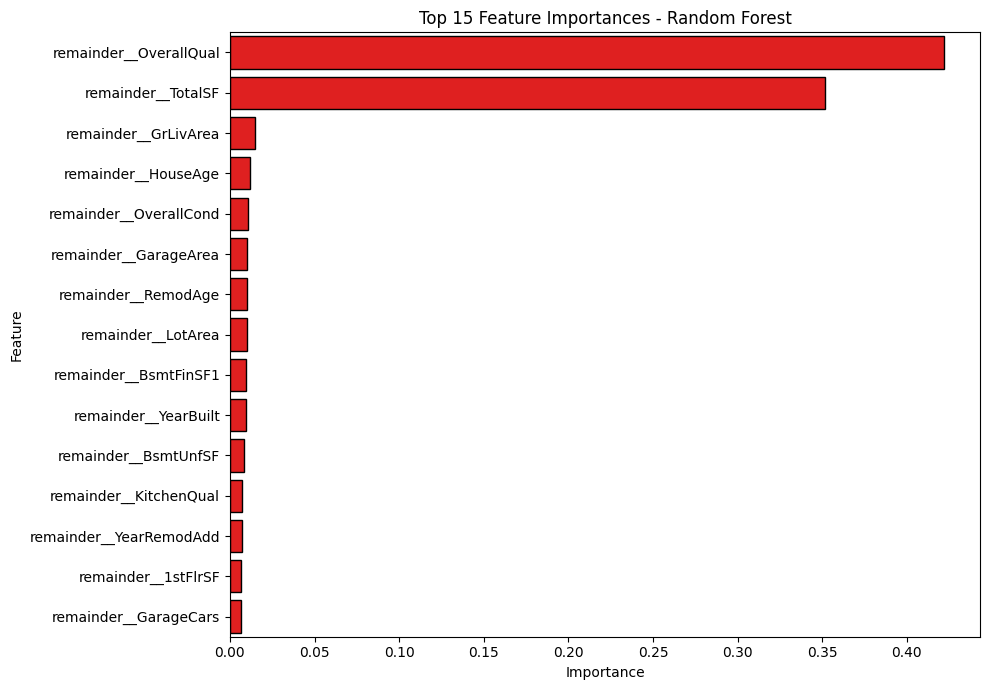

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(data = RandomForest_top15 , x = 'Importance' , y = 'Feature' , color = 'Red' , edgecolor ='black')

plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### 5.2 --> XGBoost Regressor

In [ ]:
XGB_Regression = XGBRegressor(n_estimators = 500 , learning_rate = 0.05 , max_depth = 4 , subsample =0.8 ,
colsample_bytree = 0.8 , random_state = 42)

XGB_Regression.fit(X_train_processed , y_train_log)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [ ]:
y_pred_log_xgb = XGB_Regression.predict(X_test_processed)

y_pred_xgb = np.expm1(y_pred_log_xgb)

In [ ]:
print("RMSE :", np.sqrt(mean_squared_error(y_actual, y_pred_xgb)))
print("MAE :", mean_absolute_error(y_actual, y_pred_xgb))
print("R2 Score :", r2_score(y_actual, y_pred_xgb))

RMSE : 20758.071090835525
MAE : 13965.480254708918
R2 Score : 0.9157919605470809


In [ ]:
XGB_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': XGB_Regression.feature_importances_
})

XGB_top15 = XGB_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

print(XGB_top15)

                     Feature  Importance
233     remainder__ExterQual    0.174958
228   remainder__OverallQual    0.172191
265       remainder__TotalSF    0.079981
249   remainder__KitchenQual    0.044198
254    remainder__GarageCars    0.037758
169     onehot__CentralAir_N    0.033634
234      remainder__BsmtQual    0.030858
242     remainder__GrLivArea    0.029147
245      remainder__FullBath    0.022755
248  remainder__KitchenAbvGr    0.020572
170     onehot__CentralAir_Y    0.018699
252   remainder__FireplaceQu    0.016221
266      remainder__HouseAge    0.013718
199    onehot__GarageQual_TA    0.012613
229   remainder__OverallCond    0.010565


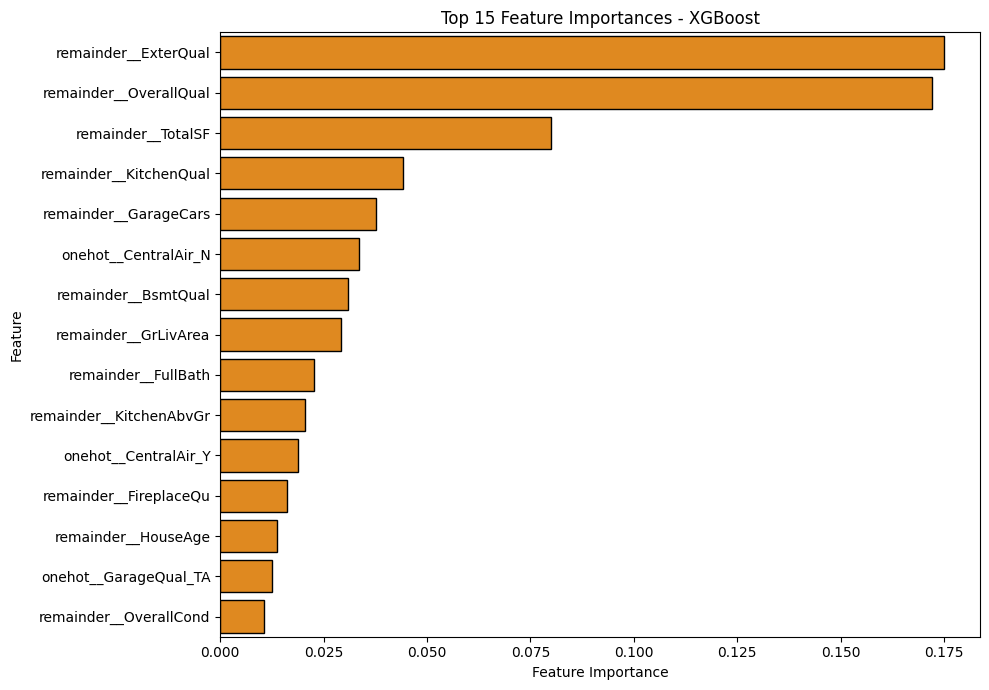

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(data = XGB_top15 , x = 'Importance' , y = 'Feature' , color = 'darkorange' , edgecolor = 'black')

plt.title('Top 15 Feature Importances - XGBoost')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### 5.3 --> Cross-Validation (on best model so far)

In [ ]:
KF = KFold(n_splits = 5 , shuffle = True , random_state = 10)

cv_rmse = []

for train_index , val_index in KF.split(X_train_processed):
    
    X_train_Fold = X_train_processed[train_index]
    X_val_Fold = X_train_processed[val_index]

    y_train_Fold = y_train_log.iloc[train_index]
    y_val_Fold = y_train_log.iloc[val_index]

    Ridge_Regression.fit(X_train_Fold, y_train_Fold)

    y_pred_log = Ridge_Regression.predict(X_val_Fold)

    y_pred = np.expm1(y_pred_log)
    y_actual_cv = np.expm1(y_val_Fold)

    RMSE = root_mean_squared_error(y_actual_cv, y_pred)

    cv_rmse.append(RMSE)

print("CV RMSE:", cv_rmse)
print("Mean CV RMSE:", np.mean(cv_rmse))
print("Std CV RMSE:", np.std(cv_rmse))

CV RMSE: [22696.77306454954, 21145.83652031946, 22724.291707356613, 21633.139004119388, 22373.14605807245]
Mean CV RMSE: 22114.63727088349
Std CV RMSE: 624.1478803012525


* The mean 5-fold CV RMSE is $22,114.64 ± $624.15, while the test-set RMSE is $19,269.88. The CV RMSE is noticeably higher than the test RMSE, indicating that the test set may be relatively easier and that Ridge's performance varies across different data splits. Overall, the model still shows reasonably consistent performance, as the standard deviation is relatively small compared with the mean RMSE.

### 5.4 --> Hyperparameter Tuning

In [ ]:
XGB_model = XGBRegressor(random_state = 42)

param_grid = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(XGB_model , param_distributions = param_grid , n_iter = 20 , cv = 3 ,
scoring = 'neg_root_mean_squared_error' , random_state = 42)

random_search.fit(X_train_processed , y_train_log)

print("Best Parameters:")
print(random_search.best_params_)


Best Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}


In [ ]:
print("Best CV RMSE:", -random_search.best_score_)

Best CV RMSE: 0.12379752252360532


In [ ]:
best_xgb = random_search.best_estimator_

y_pred_log_tuned = best_xgb.predict(X_test_processed)

In [ ]:
y_pred_tuned_xgb = np.expm1(y_pred_log_tuned)
y_actual = np.expm1(y_test_log)

In [ ]:
print("Tuned XGBoost RMSE :", root_mean_squared_error(y_actual , y_pred_tuned_xgb))
print("Tuned XGBoost MAE  :", mean_absolute_error(y_actual , y_pred_tuned_xgb))
print("Tuned XGBoost R²   :", r2_score(y_actual , y_pred_tuned_xgb))

Tuned XGBoost RMSE : 20502.244371100165
Tuned XGBoost MAE  : 13817.753063463197
Tuned XGBoost R²   : 0.9178547647737084


##  Step 6 : Model Evaluation & Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression' , 'Ridge (L2)' , 'Lasso (L1)' , 'Random Forest' , 'XGBoost'],
    'RMSE': [20767.52 , 19269.88 , 19799.02 , 24059.37 , 20758.07],
    'MAE': [ 14587.42 , 13768.06 , 14423.63 , 17008.84 , 13965.48],
    'R² Score': [0.9157 , 0.9274 , 0.9234 , 0.8869 , 0.9158],
    '5-Fold CV RMSE': ['-' , 22114.64 , '-' , '-' , '-']
})

comparison

,Model,RMSE,MAE,R² Score,5-Fold CV RMSE
0,Linear Regression,20767.52,14587.42,0.9157,-
1,Ridge (L2),19269.88,13768.06,0.9274,22114.64
2,Lasso (L1),19799.02,14423.63,0.9234,-
3,Random Forest,24059.37,17008.84,0.8869,-
4,XGBoost,20758.07,13965.48,0.9158,-


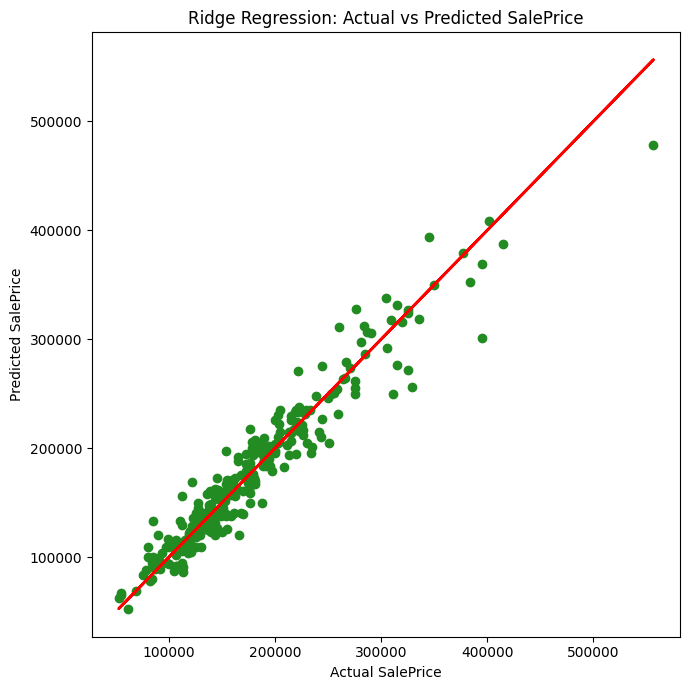

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(y_actual,y_pred_ridge,color='forestgreen')

plt.plot(y_actual , y_actual ,color='red',linewidth=2)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Ridge Regression: Actual vs Predicted SalePrice")


plt.tight_layout()
plt.show()

* Based on the actual results in your notebook, I would select Ridge Regression as the best overall model. It achieved the best test performance among the compared models, with the lowest RMSE ($19,269.88), lowest MAE ($13,768.06), and highest R² (0.9274). It is also more interpretable than Random Forest and XGBoost because its coefficients show how each feature influences the prediction, while L2 regularization helps handle correlated features and reduce overfitting. For production, Ridge is also relatively lightweight, stable, easy to deploy, and supported by your 5-fold cross-validation, although the higher CV RMSE ($22,114.64) indicates that further validation would be useful before final deployment.

## Step 7 : Rsidual Analysis & Model Interpretation

### 7.1 --> Residual Plots

In [ ]:
residuals = y_actual - y_pred_ridge

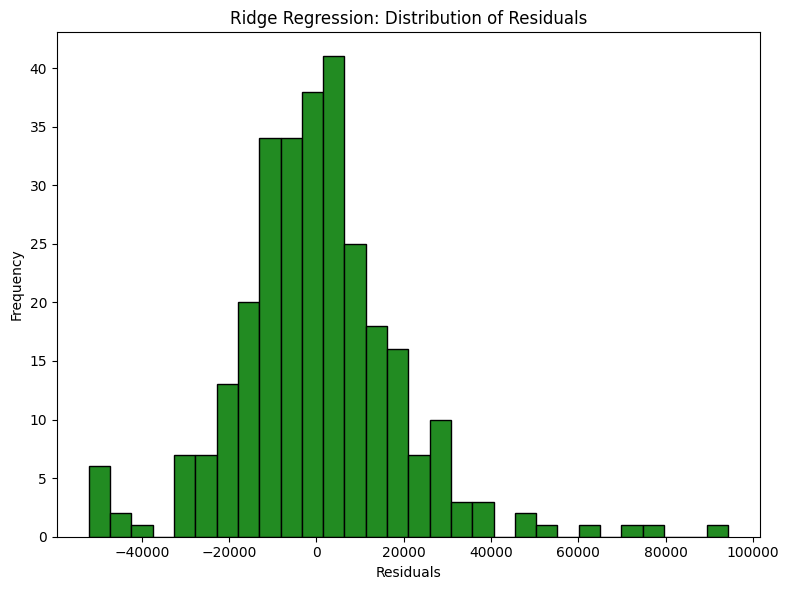

In [ ]:
plt.figure(figsize=(8, 6))

plt.hist(residuals,bins=30,color='forestgreen',edgecolor='black')

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Ridge Regression: Distribution of Residuals")

plt.tight_layout()
plt.show()

* The histogram of Ridge Regression residuals is roughly centered around zero but is not perfectly normally distributed. Most residuals are concentrated near zero, but the distribution has a noticeable right skew with a long positive tail. Therefore, the residuals are only approximately normal and show some deviation from the normality assumption.

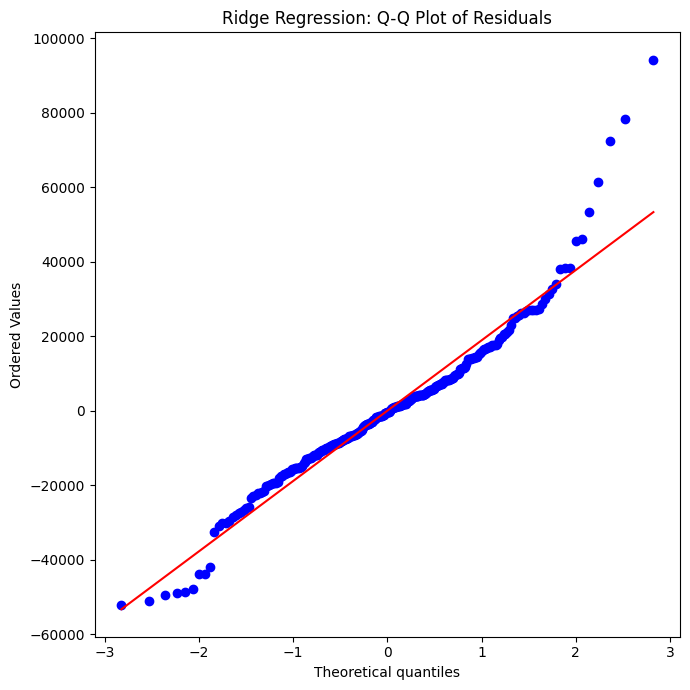

In [ ]:
plt.figure(figsize=(7, 7))

probplot(residuals, dist='norm', plot=plt)

plt.title("Ridge Regression: Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

* The Q-Q plot shows that the residuals follow the reference line reasonably well around the center, but there are significant deviations at both tails. Several points at the upper end lie far above the reference line, indicating heavy positive tails and the presence of some large residuals/outliers. Therefore, the residuals are not perfectly normally distributed and contain some extreme prediction errors.

### 7.2 --> Business Interpretation

## Top 5 most impactful features from Ridge Regression
- 1. MSZoning_C (all) — coefficient = -0.1372
- 2. Neighborhood_Crawfor — coefficient = +0.0704
- 3. OverallQual — coefficient = +0.0693
- 4. GrLivArea — coefficient = +0.0684
- 5. Functional_Typ — coefficient = +0.0662

## Step 8 : Pipeline , Deployment & Github Submission

### 8.1 --> Save the Final Pipeline

In [ ]:
final_pipeline = Pipeline([
    ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5))
])

final_pipeline.fit(X_train_processed,y_train_log)

joblib.dump(final_pipeline,'house_price_model.pkl')

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [ ]:
loaded_pipeline = joblib.load('house_price_model.pkl')

X_sample = X_test_processed[:5]
y_actual_sample = y_test.iloc[:5]

y_pred_log = loaded_pipeline.predict(X_sample)

y_pred = np.expm1(y_pred_log)

results = pd.DataFrame({
    'Actual SalePrice': y_actual_sample.values,
    'Predicted SalePrice': y_pred
})

print(results)

   Actual SalePrice  Predicted SalePrice
0            127000        149939.780651
1            187750        202703.942621
2            271000        273360.020011
3            146000        153686.091051
4            309000        317734.730143
